<a href="https://colab.research.google.com/github/Souvik-31/Medical-Anomaly-Detection/blob/main/Skip_TS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
torch.cuda.is_available(), torch.cuda.get_device_name(0)

(True, 'Tesla T4')

In [1]:
!pip install timm diffusers transformers

In [ ]:
!pip install torch torchvision torchaudio tqdm numpy pillow


In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# --- 1. THE BALANCED ARCHITECTURE (Rolled back to single-scale) ---
class TeacherStudentBase(nn.Module):
    def __init__(self):
        super().__init__()
        resnet_teacher = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.teacher = nn.Sequential(*list(resnet_teacher.children())[:-2])
        for param in self.teacher.parameters():
            param.requires_grad = False
        self.teacher.eval()

        resnet_student = models.resnet18(weights=None)
        self.student = nn.Sequential(*list(resnet_student.children())[:-2])

    def forward(self, x):
        with torch.no_grad():
            t_feat = self.teacher(x)
        s_feat = self.student(x)
        return s_feat, t_feat

class TransformerBottleneck(nn.Module):
    def __init__(self, feature_dim=512, num_heads=8, num_layers=4):
        super().__init__()
        self.embed_dim = feature_dim
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.embed_dim, nhead=num_heads,
            dim_feedforward=2048, dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):
        B, C, H, W = x.shape
        x_flat = x.view(B, C, H * W).permute(0, 2, 1)
        global_features = self.transformer(x_flat)
        out = global_features.permute(0, 2, 1).view(B, C, H, W)
        return out

class FeatureDiffusionHead(nn.Module):
    def __init__(self, channels=512):
        super().__init__()
        self.noise_predictor = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        )
    def forward(self, x, noise):
        return self.noise_predictor(x + noise)

class UnifiedAnomalyDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.texture_module = TeacherStudentBase()
        self.structure_module = TransformerBottleneck(feature_dim=512)
        self.distribution_module = FeatureDiffusionHead(channels=512)

    def forward(self, x):
        s_feat, t_feat = self.texture_module(x)
        structured_feat = self.structure_module(s_feat)
        simulated_noise = torch.randn_like(structured_feat)
        predicted_noise = self.distribution_module(structured_feat, simulated_noise)
        return s_feat, t_feat, structured_feat, predicted_noise, simulated_noise

# --- 2. THE OPTIMIZED TRAINING LOOP (Keeps weighted losses) ---
# --- 2. THE OPTIMIZED TRAINING LOOP (Keeps weighted losses) ---
def train_unified_model(model, dataloader, epochs=150):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    mse_loss = nn.MSELoss()

    model.train()
    print("Training the Model...")

    for epoch in range(epochs):
        epoch_loss = 0.0
        for images, _ in dataloader:
            images = images.to(device)
            optimizer.zero_grad()

            s_feat, t_feat, struct_feat, pred_noise, true_noise = model(images)

            # Use MSE for all to maintain stability on the small dataset
            loss_texture = mse_loss(s_feat, t_feat)
            loss_structure = mse_loss(struct_feat, s_feat.detach())
            loss_dist = mse_loss(pred_noise, true_noise)

            # Loss Balancing
            loss = (0.5 * loss_texture) + (1.5 * loss_structure) + (1.5 * loss_dist)

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # --- THE MISSING PRINT BLOCK ---
        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            avg_loss = epoch_loss / len(dataloader)
            print(f"Epoch [{epoch+1}/{epochs}] | Total Loss: {avg_loss:.4f} | "
                  f"Tex: {loss_texture.item():.4f} | Struct: {loss_structure.item():.4f} | Dist: {loss_dist.item():.4f}")
# Re-initialize and train!
unified_model = UnifiedAnomalyDetector()
train_unified_model(unified_model, train_loader, epochs=150)

Training the Model...
Epoch [1/150] | Total Loss: 5.0564 | Tex: 2.6735 | Struct: 1.2169 | Dist: 1.1099
Epoch [5/150] | Total Loss: 4.2845 | Tex: 2.3421 | Struct: 0.9620 | Dist: 1.0710
Epoch [10/150] | Total Loss: 3.6721 | Tex: 2.0109 | Struct: 0.7321 | Dist: 1.0105
Epoch [15/150] | Total Loss: 3.4385 | Tex: 1.8623 | Struct: 0.6798 | Dist: 0.9843
Epoch [20/150] | Total Loss: 3.3874 | Tex: 1.8519 | Struct: 0.6866 | Dist: 0.9664
Epoch [25/150] | Total Loss: 3.3473 | Tex: 1.7437 | Struct: 0.6974 | Dist: 0.9441
Epoch [30/150] | Total Loss: 3.3019 | Tex: 1.7066 | Struct: 0.7111 | Dist: 0.9172
Epoch [35/150] | Total Loss: 3.2403 | Tex: 1.6849 | Struct: 0.7150 | Dist: 0.8792
Epoch [40/150] | Total Loss: 3.1767 | Tex: 1.6367 | Struct: 0.7276 | Dist: 0.8378
Epoch [45/150] | Total Loss: 3.1357 | Tex: 1.6445 | Struct: 0.7275 | Dist: 0.8087
Epoch [50/150] | Total Loss: 3.0955 | Tex: 1.6293 | Struct: 0.7503 | Dist: 0.7781
Epoch [55/150] | Total Loss: 3.0508 | Tex: 1.5741 | Struct: 0.7424 | Dist: 0.7

Starting inference... please wait.
Scoring test images...


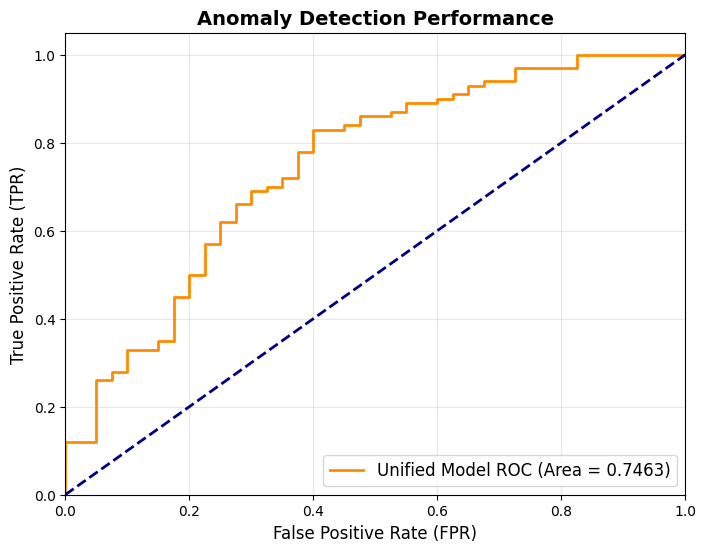


✅ Evaluation Complete! Final AUROC Score: 0.7463


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import roc_curve, auc

def evaluate_model(model, dataloader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    mse_loss = nn.MSELoss(reduction='none')

    anomaly_scores = []
    ground_truths = []

    print("Scoring test images...")
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            s_feat, t_feat, struct_feat, pred_noise, true_noise = model(images)

            tex_error = torch.mean((s_feat - t_feat) ** 2).item()
            struct_error = torch.mean((struct_feat - s_feat) ** 2).item()
            dist_error = torch.mean((pred_noise - true_noise) ** 2).item()

            total_score = (0.5 * tex_error) + (1.5 * struct_error) + (1.5 * dist_error)

            anomaly_scores.append(total_score)
            ground_truths.append(labels.item())

    return np.array(anomaly_scores), np.array(ground_truths)

print("Starting inference... please wait.")
scores, labels = evaluate_model(unified_model, test_loader)

true_anomalies = 1 - labels
fpr, tpr, thresholds = roc_curve(true_anomalies, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Unified Model ROC (Area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Anomaly Detection Performance', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"\n✅ Evaluation Complete! Final AUROC Score: {roc_auc:.4f}")

In [51]:
from google.colab import drive
drive.mount('/content/drive')

# Copy the saved model to your Google Drive
!cp unified_anomaly_detector_weights.pth "/content/drive/My Drive/"
print("Model copied to your Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat 'unified_anomaly_detector_weights1.pth': No such file or directory
Model copied to your Google Drive!
